# Building Footprint Extraction for the USA

[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeos/geoai/blob/main/docs/examples/building_footprints_usa.ipynb)

## Install package
To use the `geoai-py` package, ensure it is installed in your environment. Uncomment the command below if needed.

In [ ]:
%pip install geoai-py

## Import libraries

In [2]:
import geoai

## Download sample data

In [3]:
raster_url = (
    "/content/Dayton_area.tif"
)


In [4]:
raster_path = geoai.download_file(raster_url)

File already exists: Dayton_area.tif


## Initialize building footprint extraction pretrained model

In [6]:
extractor = geoai.BuildingFootprintExtractor()

Model path not specified, downloading from Hugging Face...


building_footprints_usa.pth:   0%|          | 0.00/176M [00:00<?, ?B/s]

Model downloaded to: /root/.cache/huggingface/hub/models--giswqs--geoai/snapshots/089548329c81f128fa12576663e7abdedb5cfa0e/building_footprints_usa.pth
Model loaded successfully


## Extract building footprints

### Option 1: Extract building footprints as raster

In [47]:
mask_path = extractor.save_masks_as_geotiff(
    raster_path=raster_path,
    output_path="building_masks.tif",
    confidence_threshold=0.2,
    mask_threshold=0.2,
)

Processing masks with parameters:
- Confidence threshold: 0.2
- Chip size: (512, 512)
- Mask threshold: 0.2
Dataset initialized with 1 rows and 2 columns of chips
Image dimensions: 524 x 479 pixels
Chip size: 512 x 512 pixels
Overlap: 25.0% (stride_x=384, stride_y=384)
CRS: EPSG:26917
Processing raster with 1 batches


100%|██████████| 1/1 [00:12<00:00, 12.68s/it]

Resizing masks at image edges (set verbose=True for details)
Object masks saved to building_masks.tif


Convert raster to vector

In [49]:
gdf = extractor.masks_to_vector(
    mask_path=mask_path,
    output_path="building_masks.geojson",
    simplify_tolerance=1.0,
)

Converting mask to GeoJSON with parameters:
- Mask threshold: 0.5
- Min object area: 100
- Max object area: None
- Simplify tolerance: 1.0
- NMS IoU threshold: 0.5
- Regularize objects: True
- Angle threshold: 15° from 90°
- Rectangularity threshold: 70.0%
Mask dimensions: (479, 524)
Mask value range: 0 to 255
Found 35 potential objects


100%|██████████| 35/35 [00:00<00:00, 1274.27it/s]


Created 22 valid polygons
Object count after NMS filtering: 22
Regularizing 22 objects...
- Angle threshold: 15° from 90°
- Min orthogonality: 30.0% of angles
- Min rectangularity: 70.0% of bounding box area


100%|██████████| 22/22 [00:00<00:00, 595.62it/s]

Regularization completed:
- Total objects: 22
- Rectangular objects: 22 (100.0%)
- Other regularized objects: 0 (0.0%)
- Unmodified objects: 0 (0.0%)
Saved 22 objects to building_masks.geojson


### Option 2: Extract building footprints as vector

In [58]:
output_path = "naip_buildings.geojson"
gdf = extractor.process_raster(
    raster_path,
    output_path="buildings.geojson",
    batch_size=6,
    confidence_threshold=0.1,
    overlap=0.5,
    nms_iou_threshold=0.5,
    min_object_area=20,
    max_object_area=None,
    mask_threshold=0.1,
    simplify_tolerance=1.0,
)

Processing with parameters:
- Confidence threshold: 0.1
- Tile overlap: 0.5
- Chip size: (512, 512)
- NMS IoU threshold: 0.5
- Mask threshold: 0.1
- Min object area: 20
- Max object area: None
- Simplify tolerance: 1.0
- Filter edge objects: True
- Edge buffer size: 20 pixels
Dataset initialized with 1 rows and 3 columns of chips
Image dimensions: 524 x 479 pixels
Chip size: 512 x 512 pixels
Overlap: 50.0% (stride_x=256, stride_y=256)
CRS: EPSG:26917
Processing raster with 1 batches


100%|██████████| 1/1 [00:22<00:00, 22.78s/it]

Objects before filtering: 40
Objects after filtering: 36
Saved 36 objects to buildings.geojson


## Regularize building footprints

In [59]:
gdf_regularized = extractor.regularize_buildings(
    gdf=gdf,
    min_area=50,
    angle_threshold=15,
    orthogonality_threshold=0.2,
    rectangularity_threshold=0.5,
)

Regularizing 36 objects...
- Angle threshold: 15° from 90°
- Min orthogonality: 20.0% of angles
- Min rectangularity: 50.0% of bounding box area


100%|██████████| 36/36 [00:00<00:00, 755.61it/s]

Regularization completed:
- Total objects: 36
- Rectangular objects: 31 (86.1%)
- Other regularized objects: 0 (0.0%)
- Unmodified objects: 5 (13.9%)


## Visualize building footprints

In [60]:
gdf.head()

,geometry,confidence,class
0,"POLYGON ((226989.421 4403991.902, 226989.121 4...",0.997946,1
1,"POLYGON ((227084.978 4404072.535, 227084.679 4...",0.997741,1
2,"POLYGON ((227054.723 4404037.764, 227054.424 4...",0.996742,1
3,"POLYGON ((227010.988 4403990.703, 227010.689 4...",0.995436,1
32,"POLYGON ((227044.539 4404038.663, 227044.539 4...",0.994020,1


In [61]:
geoai.view_vector_interactive(
    gdf, column="confidence", layer_name="Building", tiles="Satellite"
)

In [62]:
geoai.view_vector_interactive(
    gdf, column="confidence", layer_name="Building", tiles=raster_url
)

In [63]:
geoai.view_vector_interactive(
    gdf_regularized, column="confidence", layer_name="Building", tiles=raster_url
)

Using confidence values (range: 0.11 - 1.00)
Visualization saved to naip_buildings.png
Sample visualization saved to naip_buildings_sample.png


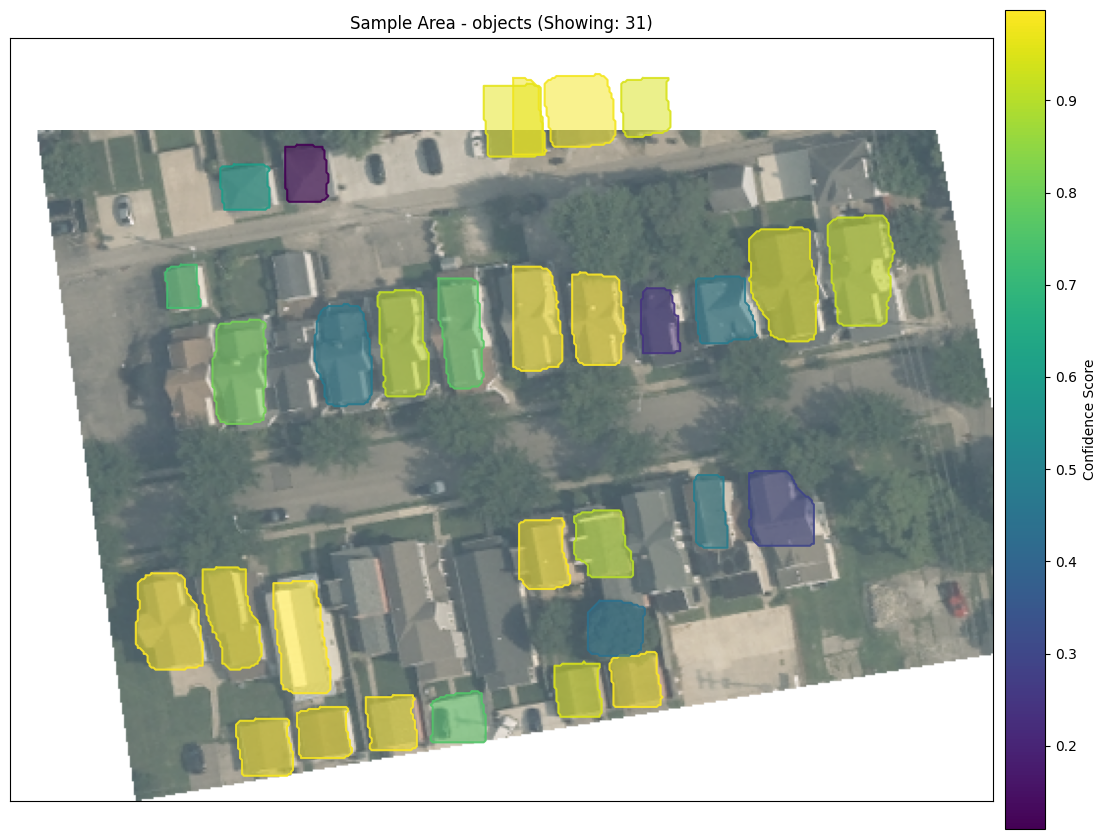

In [64]:
extractor.visualize_results(raster_path, gdf, output_path="naip_buildings.png")

Using confidence values (range: 0.11 - 1.00)
Visualization saved to naip_buildings_regularized.png
Sample visualization saved to naip_buildings_regularized_sample.png


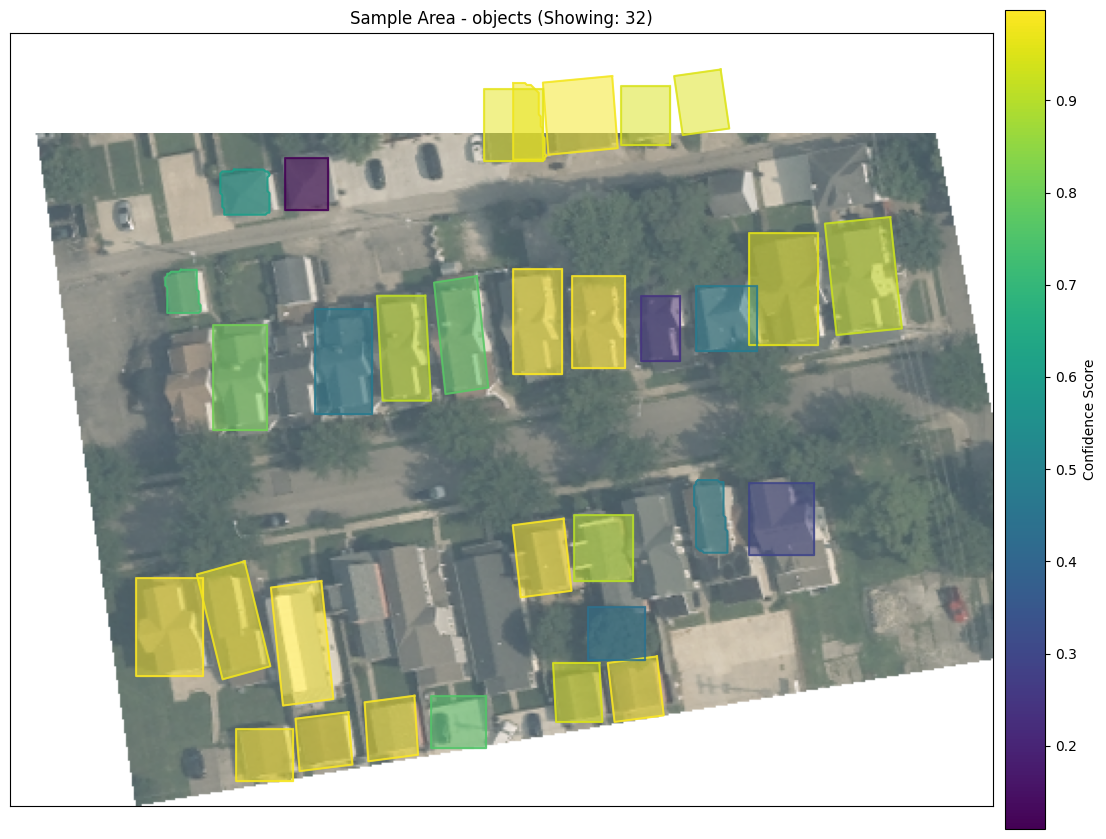

In [65]:
extractor.visualize_results(
    raster_path, gdf_regularized, output_path="naip_buildings_regularized.png"
)